In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [104]:
data = pd.read_csv('housing.csv')

In [105]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [107]:
data.dropna(inplace=True)

In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [109]:
from sklearn.model_selection import train_test_split
x = data.drop('median_house_value',axis=1)
y = data['median_house_value']

In [110]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2)  #X_train = training data, X_test = testing data, y_train = training labels, y_test = testing labels

In [111]:
train_data = X_train.join(y_train) 

In [112]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
3603,-118.47,34.23,22.0,8350.0,2717.0,9135.0,2452.0,2.5008,<1H OCEAN,160000.0
17400,-120.44,34.93,15.0,868.0,244.0,1133.0,253.0,2.0995,<1H OCEAN,87500.0
4268,-118.31,34.10,36.0,2288.0,1033.0,3030.0,890.0,1.5328,<1H OCEAN,250000.0
19187,-122.66,38.45,26.0,2081.0,339.0,906.0,323.0,4.4375,<1H OCEAN,293500.0
7122,-118.03,33.91,32.0,4040.0,832.0,2526.0,798.0,3.2143,<1H OCEAN,160100.0
...,...,...,...,...,...,...,...,...,...,...
16673,-120.81,35.19,14.0,3414.0,802.0,1236.0,632.0,3.7635,NEAR OCEAN,336200.0
3874,-118.54,34.20,37.0,1600.0,349.0,1012.0,366.0,4.1597,<1H OCEAN,201600.0
11413,-117.95,33.70,17.0,5781.0,924.0,2585.0,915.0,5.3430,<1H OCEAN,231900.0
6496,-118.00,34.08,23.0,1627.0,318.0,1279.0,289.0,4.6467,INLAND,185100.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

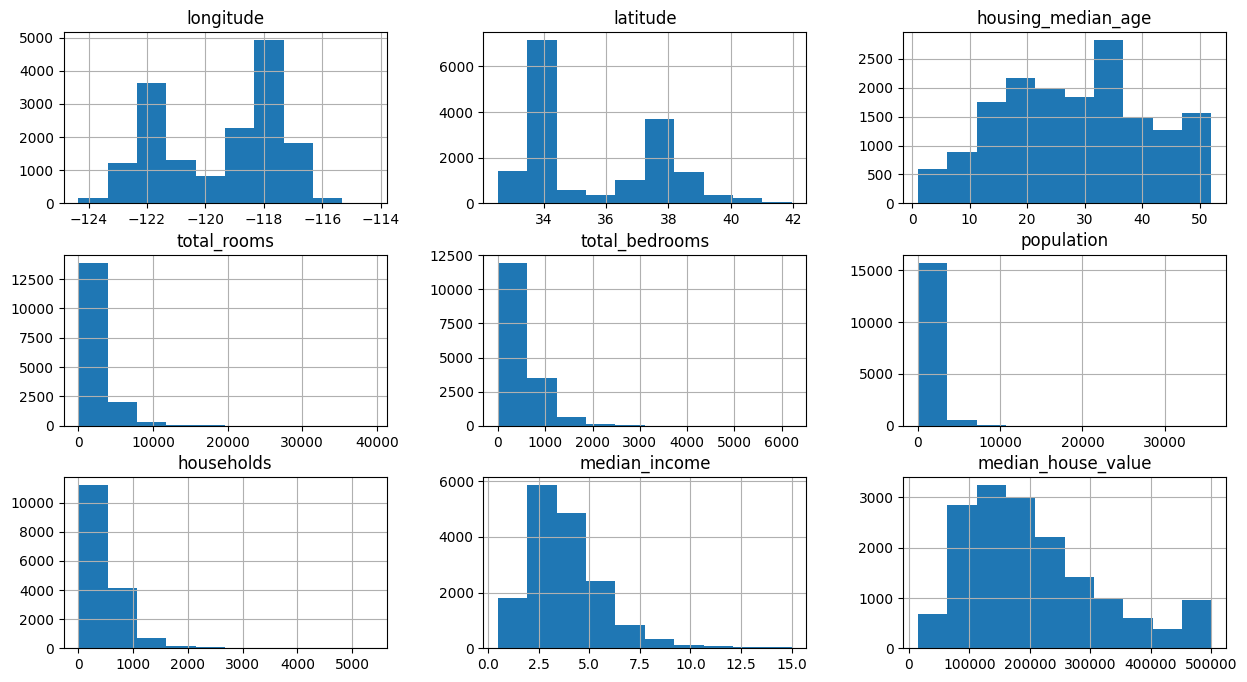

In [113]:
train_data.hist(figsize=(15,8))

<Axes: >

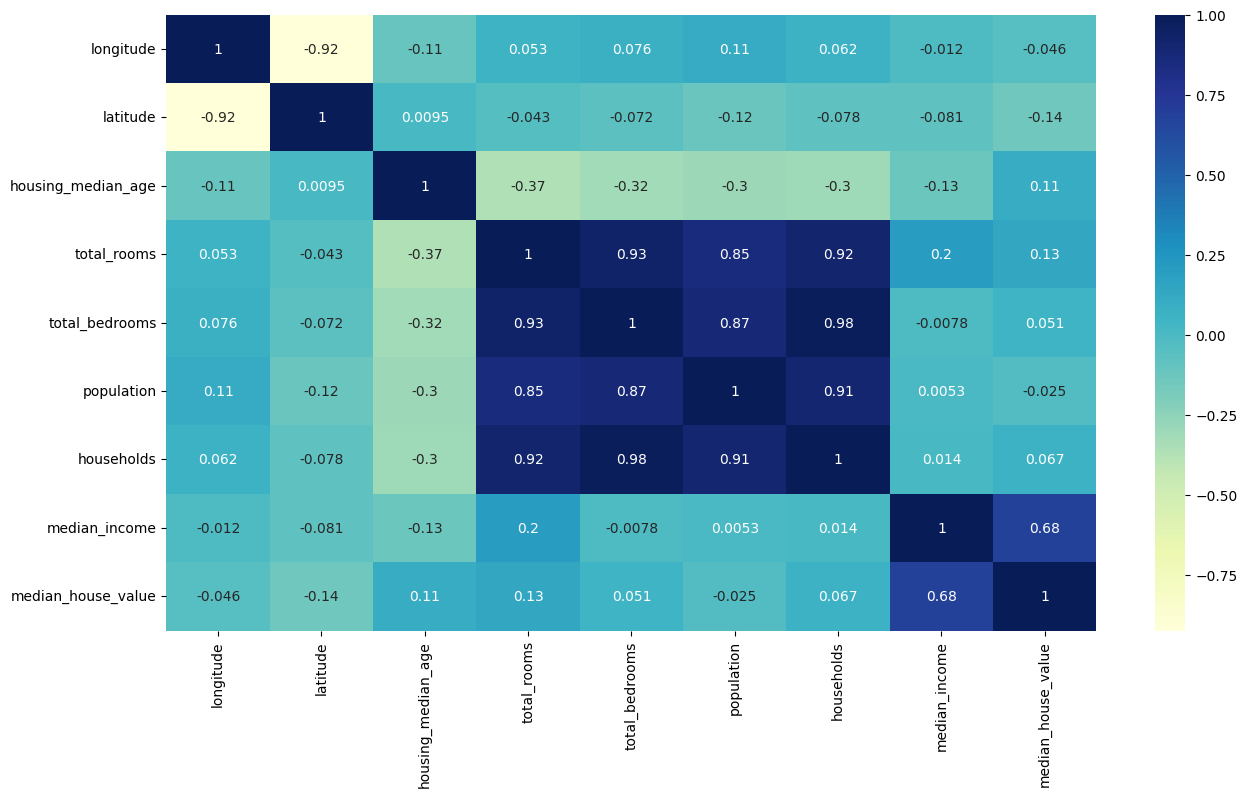

In [114]:
plt.figure(figsize=(15,8))
# The numeric_only=True argument is the key here
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [115]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

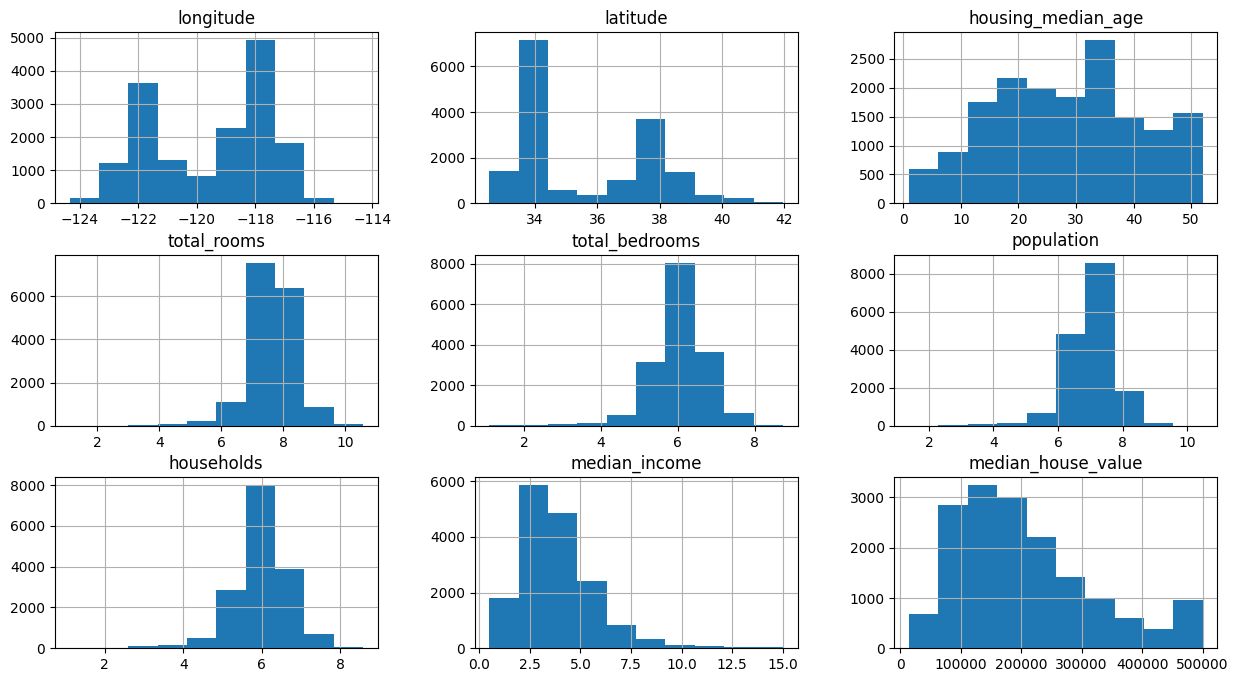

In [116]:
train_data.hist(figsize=(15,8))

In [117]:
train_data.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     7268
INLAND        5178
NEAR OCEAN    2080
NEAR BAY      1818
ISLAND           2
Name: count, dtype: int64

In [118]:
train_data = train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop('ocean_proximity',axis=1)

<Axes: >

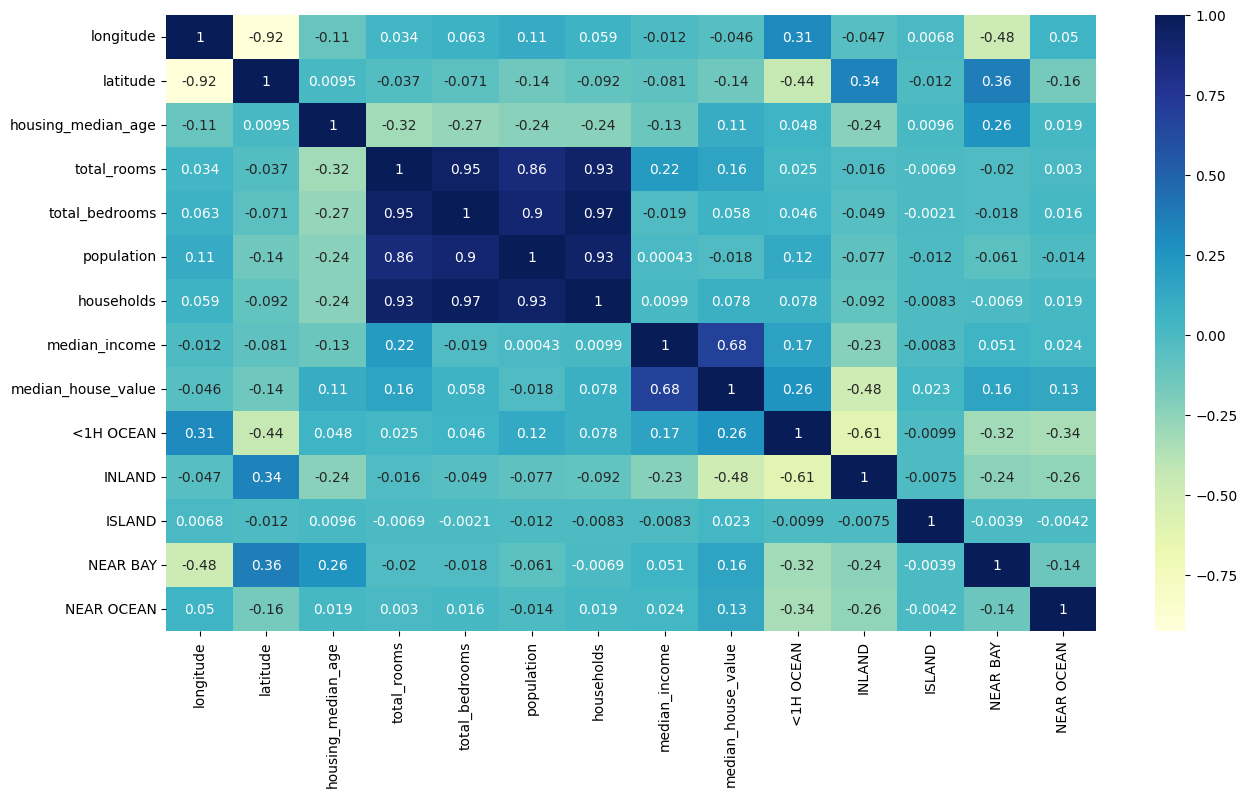

In [119]:
plt.figure(figsize=(15,8))
# The numeric_only=True argument is the key here
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

<Axes: xlabel='latitude', ylabel='longitude'>

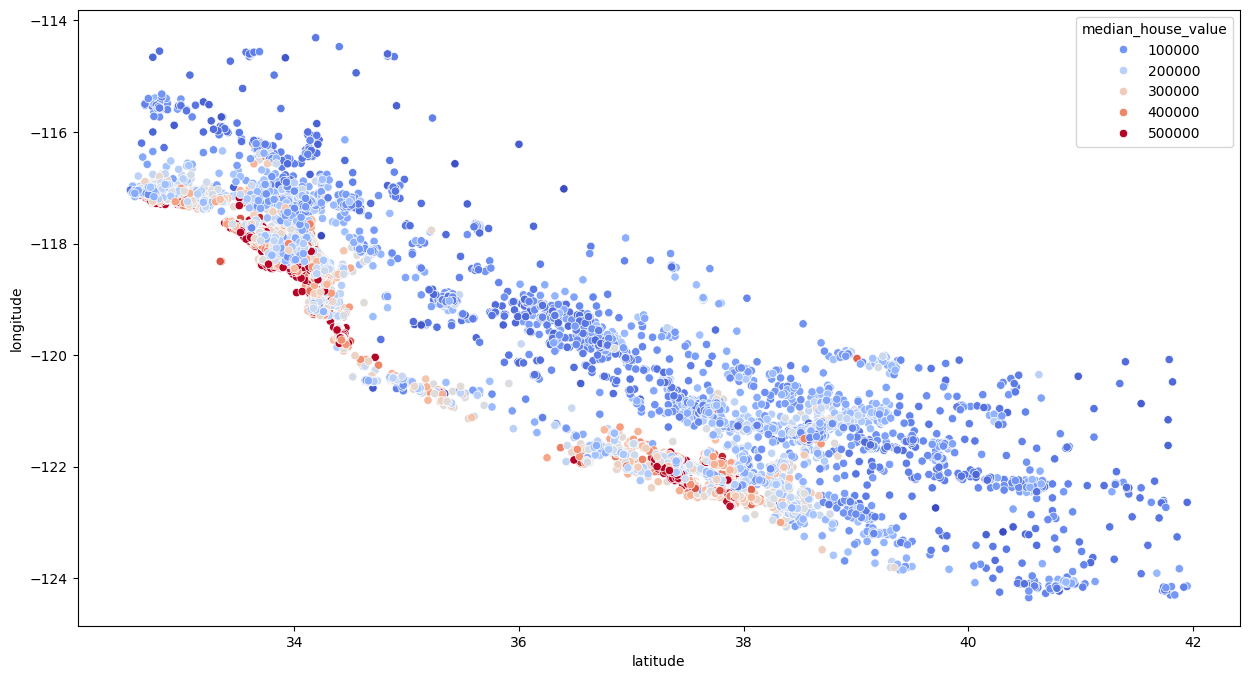

In [120]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='latitude',y='longitude',data=train_data, hue='median_house_value',palette='coolwarm')

In [121]:
train_data['bedrooms_ratio'] = train_data['total_bedrooms']/train_data['total_rooms']
train_data['households_rooms'] = train_data['households']/train_data['total_rooms'] 

<Axes: >

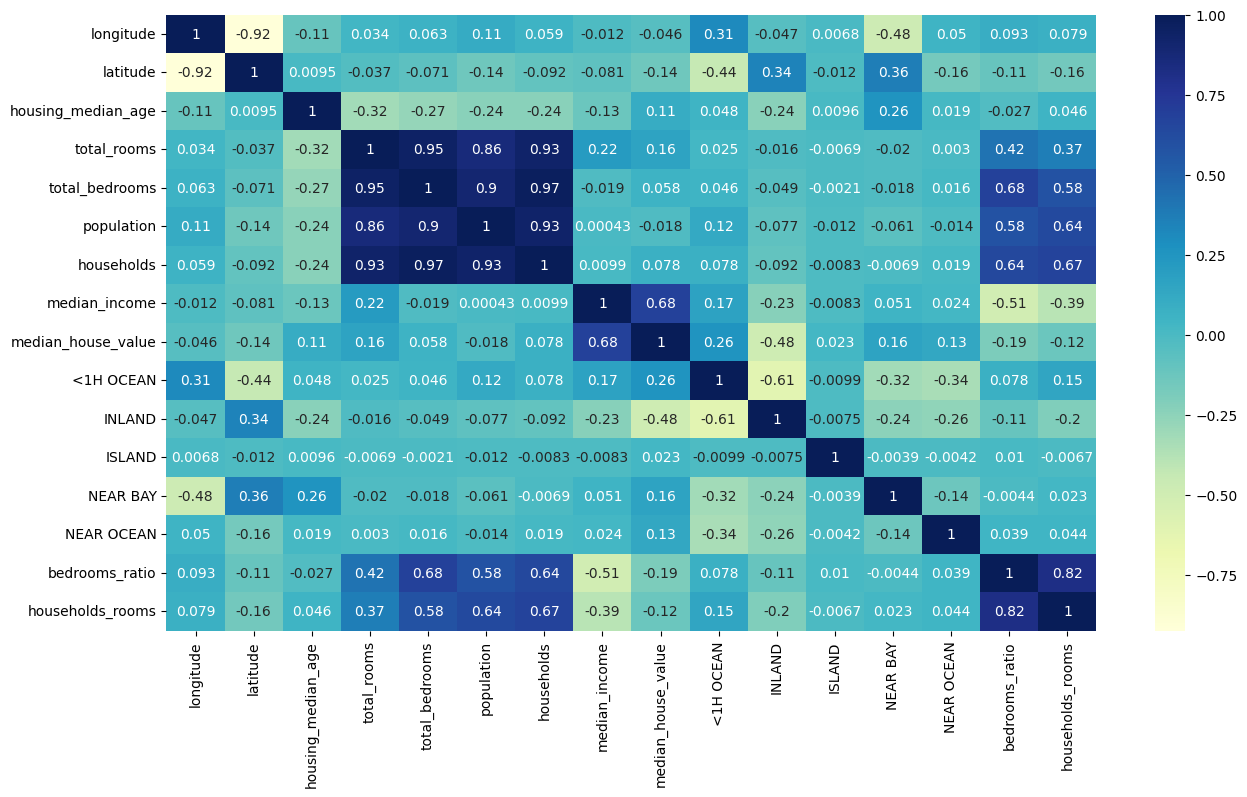

In [122]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [123]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train,y_train = train_data.drop('median_house_value',axis=1), train_data['median_house_value']
X_train_s = scaler.fit_transform(X_train)


reg = LinearRegression()

reg.fit(X_train_s,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [124]:
test_data = X_test.join(y_test) 

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

test_data = test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop('ocean_proximity',axis=1)

test_data['bedrooms_ratio'] = test_data['total_bedrooms']/test_data['total_rooms']
test_data['households_rooms'] = test_data['households']/test_data['total_rooms'] 


In [125]:
X_test,y_test = test_data.drop('median_house_value',axis=1), test_data['median_house_value'] 

In [126]:
X_test_s = scaler.transform(X_test)

In [127]:
reg.score(X_test_s,y_test)

0.6812817568126563

In [128]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

# forest.fit(X_train,y_train)
forest.fit(X_train_s,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [129]:
# forest.score(X_test,y_test)
forest.score(X_test_s,y_test)

0.8237681318313015

In [135]:
from sklearn.model_selection import GridSearchCV
forest = RandomForestRegressor()

param_grid = {
    "n_estimators": [100,200,300],
    "min_samples_split": [2,4],
    "max_depth": [None,4,8] 
}

grid_search = GridSearchCV(forest,param_grid,cv=5,scoring='neg_mean_squared_error',n_jobs=-1,return_train_score=True)

grid_search.fit(X_train_s,y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 4, ...], 'min_samples_split': [2, 4], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,300


In [131]:
best_forest = grid_search.best_estimator_

In [132]:
best_forest.score(X_test_s,y_test)

0.8205612478511786